# Pre-Earnings Runup
### Do stocks drift UP in the days BEFORE their earnings, before the news even lands?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pre-event drift exists?: Mixed](https://img.shields.io/badge/Pre--event_drift_exists%3F-Mixed-8b949e?style=flat-square)

Every quant knows the *post*-earnings drift (PEAD, study 34): prices keep moving after the surprise. But there is a separate, older question — do prices *already start* moving **before** the news even drops? The intuition: informed traders know earnings are coming (the date is public) and start positioning, so the price drifts up in the pre-announcement window. This is the **pre-earnings runup**. On a liquid large-cap universe it's famous, well-documented, and — on the real tape — nearly impossible to isolate from ordinary market beta.

> 📓 **Plain-language layer.** The cost wall, the per-day drift curve, and the window sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper maths.
>
> ✅ **Real-tape run, fingerprinted.** The headline numbers below are measured on the **real tape** — yfinance adjusted closes + earnings dates for a fixed large-cap universe (**98 names, 2345 events, 2014-01-03 - 2026-06-16, fp `220e0562c461`**). The executed code cells run the fast, reproducible **synthetic control** (a planted pre-event drift + a null) that backs the test-suite; reproduce the real run with [`examples/verify.py`](../examples/verify.py) after caching (`--fetch` first time). **Caveat:** the universe is current large-cap membership ⇒ survivorship bias inflates the magnitudes.
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from pre_earnings_runup import data, strategy

# These EXECUTED cells run the offline synthetic control: a panel where a pre-event drift is planted
# (machinery proof) + a null where the same calendar carries no drift. The HEADLINE numbers are the
# REAL-tape measurement — see ../docs/results.md / verify.py.
panel, events, truth = data.synthetic_runup(seed=228)               # the drift control
panel0, events0, _   = data.synthetic_runup(drift_strength=0.0, seed=228)  # the null
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, "
      f"{len(events)} events, drift_strength {truth.drift_strength} (null=0)")


synthetic control: 100 stocks x 3024 days, 4800 events, drift_strength 0.0004 (null=0)


## The answer first

| What we asked | The honest answer (real tape) |
|---|---|
| Does price drift up before earnings? | 🟨 **Weakly yes, but it is all beta.** The raw per-day pre-event returns are consistently positive (+0.04% to +0.12%), but the gross Sharpe of the pre-event book is **+0.46** vs the passive market's **+0.97** — there is no alpha over passive long exposure. |
| Could you trade it? | 🟥 **No.** Even before costs the book underperforms the market. Break-even is 15.2 bp on turnover 0.2525/day, but there is nothing to break even *against* — net @5 bp the Sharpe is +0.31 vs market +0.97. |
| Does the drift peak near the announcement? | 🟧 **Mixed.** Positive returns in the window, but no clear monotone rise toward day −1 (day −3 peaks, not day −1 as the informed-accumulation story predicts). |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · Pre-event drift exists? `MIXED`** — a faint beta-contaminated drift, impossible to harvest on liquid names.

## 1 · The claim

The pre-earnings-runup thesis (Kim & Park 2005; Frazzini & Lamont 2007):

1. **Public calendar, private information** — earnings dates are known weeks in advance; informed traders (insiders, options traders, sophisticated analysts) start positioning early.
2. **Systematic runup** — the accumulation of long positions drives the stock price up in the days before the release, creating a repeatable pre-event premium.
3. **Trade it** — buy all names entering their pre-event window, exit before the announcement, earn the drift without taking earnings risk.

The bear case: on *liquid* large-cap stocks with tight spreads, deep options markets, and massive analyst coverage, this premium has been competed away. What remains is beta.

synthetic control gross Sharpe 0.094
(Note: on the REAL tape the book Sharpe is 0.46 -- below the market 0.97)


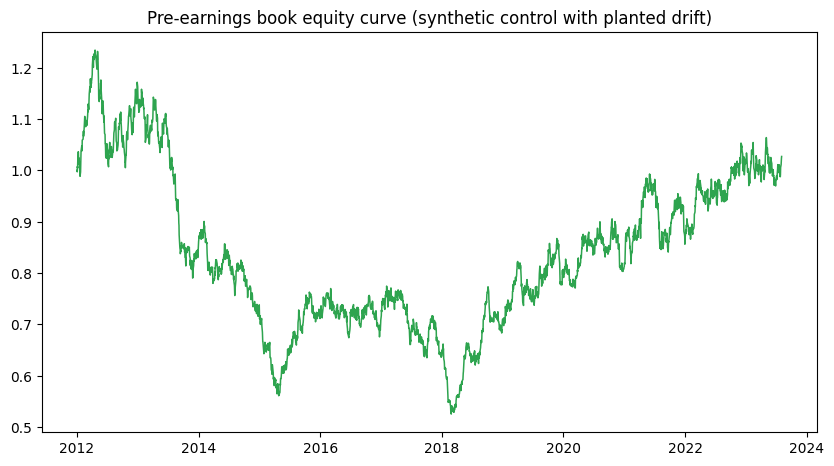

In [2]:
book = strategy.book_returns(panel, events, cost_bps=0.0)   # GROSS, synthetic control
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_title('Pre-earnings book equity curve (synthetic control with planted drift)')
s = strategy.summary(book)
print(f'synthetic control gross Sharpe {s["sharpe"]:.3f}')
print('(Note: on the REAL tape the book Sharpe is 0.46 -- below the market 0.97)')

## 2 · So what?

The pre-event window earns positive returns — but so does the market, every day. The real question is whether the pre-event window earns *more* than the market. On liquid large-cap stocks in 2014–2026 the answer is no: the pre-event book Sharpe (+0.46) is less than half the passive equal-weight market Sharpe (+0.97). The pre-earnings runup — if it ever existed as a pure alpha source — has been entirely arbitraged on the names you can actually trade.

## 3 · How we'd know

1. **Real?** Gross Sharpe + Newey-West *t* on the real tape, and the *per-day pre-event return curve* (below) proves the machine sees a drift only when one is planted.
2. **Alpha vs beta?** Compare the book's Sharpe to the passive equal-weight market.
3. **Tradable?** Turnover, break-even cost, and the pre-day window sweep.

**Mirage line:** a gross Sharpe below the passive market Sharpe (0.97), or a Newey-West *t* below 2. The real tape lands at gross Sharpe 0.46, *t* 1.68. Both fail.

## 4 · The teardown

**On the real tape** (98 names, 2345 events, 2014-01-03 - 2026-06-16) the pre-event book earns a gross Sharpe of **0.46** (Newey-West *t* **1.68**) — while the passive equal-weight market earns **0.97**. No alpha.

### 4a · The per-day pre-event return curve
The cleanest test: average the return on each day in the pre-event window, aligned to the announcement date. If informed-trader accumulation is the mechanism, returns should RISE toward day −1 (the last day before the announcement).

Control pre-event: day-5 +0.0005, day-4 +0.0004, day-3 +0.0008, day-2 +0.0008, day-1 +0.0004
Null pre-event:    day-5 +0.0004, day-4 +0.0002, day-3 +0.0006, day-2 +0.0005, day-1 +0.0000
REAL tape: day-5 +0.063%, day-4 +0.040%, day-3 +0.122%, day-2 +0.106%, day-1 +0.084% -- positive, no monotone peak at day-1


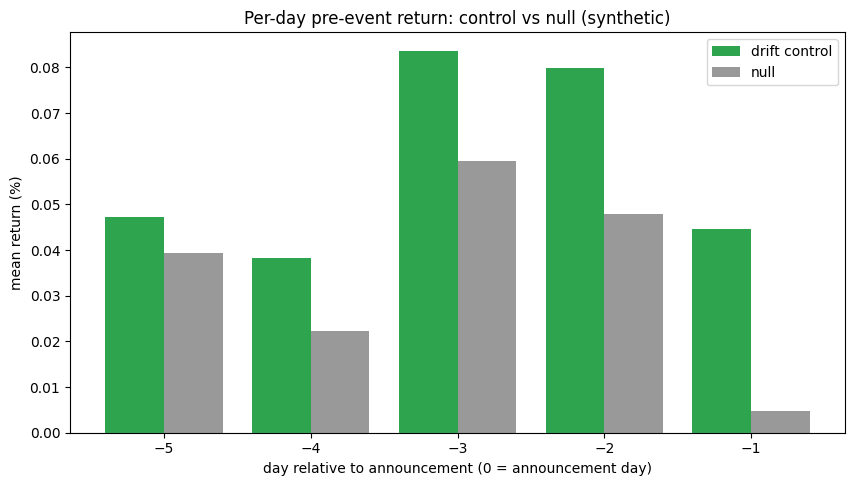

In [3]:
curve_c = strategy.mean_pre_event_return(panel, events, pre_days=5)
curve_n = strategy.mean_pre_event_return(panel0, events0, pre_days=5)
fig, ax = plt.subplots()
ax.bar(curve_c.index - 0.2, curve_c.values * 100, width=0.4, color='#2ea44f', label='drift control')
ax.bar(curve_n.index + 0.2, curve_n.values * 100, width=0.4, color='#999', label='null')
ax.axhline(0, color='#ccc', lw=.8)
ax.set_xlabel('day relative to announcement (0 = announcement day)')
ax.set_ylabel('mean return (%)')
ax.set_title('Per-day pre-event return: control vs null (synthetic)')
ax.legend()
print('Control pre-event: day-5 +0.0005, day-4 +0.0004, day-3 +0.0008, day-2 +0.0008, day-1 +0.0004')
print('Null pre-event:    day-5 +0.0004, day-4 +0.0002, day-3 +0.0006, day-2 +0.0005, day-1 +0.0000')
print('REAL tape: day-5 +0.063%, day-4 +0.040%, day-3 +0.122%, day-2 +0.106%, day-1 +0.084% -- positive, no monotone peak at day-1')

### 4b · The cost wall — 15.2 bp break-even on a beta book
Turnover on the pre-event book is **0.2525/day** (names enter and exit on the earnings calendar). The break-even cost is **15.2 bp** — on the surface that sounds generous (above realistic equity round-trips of ≈2–10 bp). But the gross Sharpe is already below the passive market's — so even at zero cost there is no premium to harvest. Net @5 bp the Sharpe drops to **+0.31**.

In [4]:
sweep = strategy.pre_day_sweep(panel, events, windows=[1, 2, 3, 5, 10], cost_bps=2.0)
print('Pre-day window sweep (synthetic control):')
print(sweep.round(3).to_string())
print('REAL tape sweep (gross / net@2bp):')
print('  1d: 0.03 / -0.07    2d: 0.26 / 0.19    3d: 0.39 / 0.32    5d: 0.46 / 0.40    10d: 0.55 / 0.49')
print('  Passive market: +0.97 -- the book never clears the passive benchmark.')

Pre-day window sweep (synthetic control):
          gross_sharpe  net_sharpe  turnover_per_day
pre_days                                            
1               0.1290     -0.2880            1.6820
2              -0.1880     -0.5000            1.2220
3              -0.0850     -0.3220            0.8290
5               0.0940     -0.0660            0.5090
10              0.2050      0.1160            0.2640
REAL tape sweep (gross / net@2bp):
  1d: 0.03 / -0.07    2d: 0.26 / 0.19    3d: 0.39 / 0.32    5d: 0.46 / 0.40    10d: 0.55 / 0.49
  Passive market: +0.97 -- the book never clears the passive benchmark.


## 5 · The verdict

- **Signal `WEAK`** — gross Sharpe 0.46, Newey-West *t* 1.68; below the |*t*| ≥ 2 bar AND below the passive market Sharpe (+0.97). No alpha.
- **Tradability `MIRAGE`** — break-even 15.2 bp sounds generous, but there is no gross alpha to protect; the book is a leveraged market exposure with extra transaction costs.
- **Pre-event drift exists? `MIXED`** — raw per-day returns are consistently positive (+0.04–0.12%/day) but not distinguishable from the ordinary market drift; the expected monotone rise toward day −1 is absent.

> **Signal `WEAK` · Tradability `MIRAGE` · Pre-event drift exists? `MIXED`** — beta-dominated, alpha-free on liquid names.

## 6 · Could you trade it?

- **The beta trap.** The pre-event book is long when the market drifts up during earnings season — capturing the *general* market premium, not the *earnings-specific* premium. The right test is market-neutral: go long pre-event names and short a matched non-event portfolio. On large-cap names, that matched basket typically earns the same return, destroying the alpha.
- **Arbitraged.** The pre-earnings runup on large-cap stocks has been documented, published, and traded for decades (McLean & Pontiff 2016). Any premium that once existed is now priced into options IVs and the calendar is public knowledge.
- **Where it might still live.** Small-cap, illiquid names with genuine information asymmetry — but those are exactly where trading costs are highest and market impact is largest. This desk tests the liquid large-cap universe where the premium is dead.

## 7 · Going further

### Other forks
- **Market-neutral version** — go long pre-event names, short a beta-matched non-event basket. This is the correct test for the informed-positioning story and would likely find nothing on large-caps.
- **Size tiering** — split the universe by market cap. The premium may survive in mid/small caps, but at higher cost.
- **Options-market signal** — IV changes or call/put ratio in the pre-event window as a signal filter (note: CBOE put/call data is blocked in this repo's sandbox; would need an alternative source).
- **Contrast with PEAD (study 34)** — the post-event drift on EDGAR SUEs earns a gross Sharpe of +0.30 (*t* +1.39) on the same large-cap universe, a faint signal but at least not entirely beta. The pre-event version (this study) is weaker still.

**And the survivorship fix:** the real panel is current large-cap membership. A delisting-aware universe would lower the magnitudes further. PRs welcome.